# SECTION 1 — Imports and Global Settings


In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import yaml


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)


date = "20260508"
result_date = "2026-05-08"

time = "033947"
result_time = "03-20"

config_path = Path(
    f"../results/{date}_{time}_balanced/consumer/pipeline-configmap.yaml"
)

#INPUT_DIR = Path("../results/20260507_233056_balanced/consumer/consumer-sts-*_metrics/2026-05-07-23-06/") #POLL_MAX_MSG: 200 
#INPUT_DIR = Path("../results/20260508_015422_balanced/consumer/consumer-sts-*_metrics/2026-05-08-01-38/") # POLL_MAX_MSG: "50"
#INPUT_DIR = Path("../results/20260508_023438_balanced/consumer/consumer-sts-*_metrics/2026-05-08-02-17/") # POLL_MAX_MSG: "25"
INPUT_DIR = Path(f"../results/{date}_{time}_balanced/consumer/consumer-sts-*_metrics/{result_date}-{result_time}/") # POLL_MAX_MSG: "10"

#POLL_MAX_MSG = 10

OUTPUT_DIR = Path("./balanced_analysis_output")
figures_dir = OUTPUT_DIR / "figures" 
figures_dir.mkdir(exist_ok=True, parents=True)

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

BUCKET_SEC = 5

print("INPUT_DIR =", INPUT_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)


with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

POLL_MAX_MSG = int(cfg["data"]["POLL_MAX_MSG"])

print(POLL_MAX_MSG)


INPUT_DIR = ../results/20260508_033947_balanced/consumer/consumer-sts-*_metrics/2026-05-08-03-20
OUTPUT_DIR = balanced_analysis_output
5


# SECTION 2 — Helper Functions


In [218]:
def read_many_csv(pattern):
    files = sorted(glob.glob(str(pattern), recursive=True))

    if not files:
        print(f"[WARN] No files found for: {pattern}")
        return pd.DataFrame()

    dfs = []

    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = os.path.basename(f)
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Failed reading {f}: {e}")

    return pd.concat(dfs, ignore_index=True)

def q(series, p):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return float(s.quantile(p))

def coefficient_of_variation(series):
    s = pd.to_numeric(series, errors="coerce").dropna()

    if len(s) == 0:
        return np.nan

    mean = s.mean()

    if mean == 0:
        return np.nan

    return float(s.std() / mean)

def add_time_bucket(df, ts_col, bucket_sec=5):

    out = df.copy()

    out[ts_col] = pd.to_numeric(out[ts_col], errors="coerce")

    out = out.dropna(subset=[ts_col])

    out["bucket"] = (
        (out[ts_col] // bucket_sec).astype(int) * bucket_sec
    )

    out["time_rel_sec"] = (
        out["bucket"] - out["bucket"].min()
    )

    return out


In [233]:
# SECTION 3 — Load CSV Files
metrics_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_metrics_*.csv"
)

lag_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_partition_lag_*.csv"
)

per_msg_df = read_many_csv(
    INPUT_DIR / "**" / "per_message_latency_*.csv"
)

rebalance_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_rebalance_events_*.csv"
)

print("metrics_df:", metrics_df.shape)
print("lag_df:", lag_df.shape)
print("per_msg_df:", per_msg_df.shape)
print("rebalance_df:", rebalance_df.shape)


metrics_df: (30, 21)
lag_df: (8600, 9)
per_msg_df: (6409, 9)
rebalance_df: (5, 7)


In [234]:
metrics_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_metrics_*.csv"
)

lag_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_partition_lag_*.csv"
)

per_msg_df = read_many_csv(
    INPUT_DIR / "**" / "per_message_latency_*.csv"
)

rebalance_df = read_many_csv(
    INPUT_DIR / "**" / "consumer_rebalance_events_*.csv"
)

print("metrics_df:", metrics_df.shape)
print("lag_df:", lag_df.shape)
print("per_msg_df:", per_msg_df.shape)
print("rebalance_df:", rebalance_df.shape)


metrics_df: (30, 21)
lag_df: (8600, 9)
per_msg_df: (6409, 9)
rebalance_df: (5, 7)


In [235]:
nonzero_lag_df = lag_df[lag_df["lag"] > 0]

nonzero_lag_df.count()[0]

1823

# SECTION 4 — Convert Numeric Columns


In [236]:
metrics_numeric = [
    "window_total",
    "window_viol",
    "msg_rate_window",
    "lat_p95_ms",
    "lat_p99_ms",
    "cpu_percent",
    "mem_percent",
    "uptime_sec",
    "total_lag",
    "max_lag",
    "lag_skew_ratio",
    "consumed_total",
    "assigned_partitions",
]

for c in metrics_numeric:
    if c in metrics_df.columns:
        metrics_df[c] = pd.to_numeric(
            metrics_df[c],
            errors="coerce"
        )

lag_numeric = [
    "ts_epoch",
    "partition",
    "current_offset",
    "high_watermark",
    "lag",
]

for c in lag_numeric:
    if c in lag_df.columns:
        lag_df[c] = pd.to_numeric(
            lag_df[c],
            errors="coerce"
        )

per_msg_numeric = [
    "recv_ts",
    "producer_ts",
    "e2e_ms",
    "partition",
    "offset",
    "index",
]

for c in per_msg_numeric:
    if c in per_msg_df.columns:
        per_msg_df[c] = pd.to_numeric(
            per_msg_df[c],
            errors="coerce"
        )

print("[OK] Numeric conversion completed")


[OK] Numeric conversion completed


In [237]:
summary = {}

summary["traffic_mode"] = (
    metrics_df["traffic_mode"].dropna().iloc[0]
)

summary["consumer_pods"] = (
    metrics_df["pod"].nunique()
)

summary["mean_assigned_partitions"] = (
    metrics_df["assigned_partitions"].mean()
)

summary["sampled_messages"] = len(per_msg_df)

summary["lat_p50_ms"] = q(per_msg_df["e2e_ms"], 0.50)
summary["lat_p90_ms"] = q(per_msg_df["e2e_ms"], 0.90)
summary["lat_p95_ms"] = q(per_msg_df["e2e_ms"], 0.95)
summary["lat_p99_ms"] = q(per_msg_df["e2e_ms"], 0.99)
summary["lat_p999_ms"] = q(per_msg_df["e2e_ms"], 0.999)

summary["lat_max_ms"] = (
    per_msg_df["e2e_ms"].max()
)

summary["tail_amp_p99_p50"] = (
    summary["lat_p99_ms"] /
    summary["lat_p50_ms"]
)

summary_df = pd.DataFrame([summary])

summary_df


,traffic_mode,consumer_pods,mean_assigned_partitions,sampled_messages,lat_p50_ms,lat_p90_ms,lat_p95_ms,lat_p99_ms,lat_p999_ms,lat_max_ms,tail_amp_p99_p50
0,balanced,5,10.0,6409,13.777256,128.093672,723.958206,2426.099215,3790.148609,4176.792383,176.094515


In [239]:
#lag_df["lag"].describe()

In [240]:
# Fix old metrics_df throughput using consumed_total delta

metrics_fixed = metrics_df.copy()

metrics_fixed["uptime_sec"] = pd.to_numeric(metrics_fixed["uptime_sec"], errors="coerce")
metrics_fixed["consumed_total"] = pd.to_numeric(metrics_fixed["consumed_total"], errors="coerce")

metrics_fixed = metrics_fixed.sort_values(["pod", "uptime_sec"])

metrics_fixed["delta_msgs"] = (
    metrics_fixed
    .groupby("pod")["consumed_total"]
    .diff()
)

metrics_fixed["delta_time"] = (
    metrics_fixed
    .groupby("pod")["uptime_sec"]
    .diff()
)

metrics_fixed["true_msg_rate"] = (
    metrics_fixed["delta_msgs"] / metrics_fixed["delta_time"]
)

# Remove startup rows and empty rows after producer stopped
metrics_fixed = metrics_fixed[
    (metrics_fixed["delta_msgs"] > 0) &
    (metrics_fixed["delta_time"] > 0)
].copy()

metrics_fixed[["pod", "uptime_sec", "consumed_total", "delta_msgs", "delta_time", "true_msg_rate", "lat_p99_ms"]].head()
metrics_df = metrics_fixed
metrics_fixed["true_msg_rate"].describe()


count     25.000000
mean     141.691460
std       89.857325
min       35.300386
25%       54.471599
50%      120.616737
75%      242.774374
max      247.934985
Name: true_msg_rate, dtype: float64

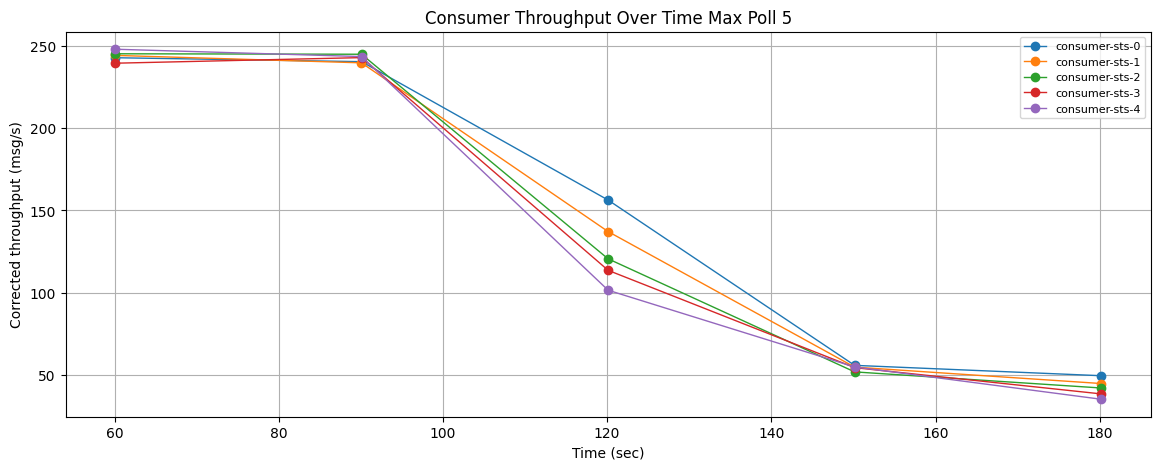

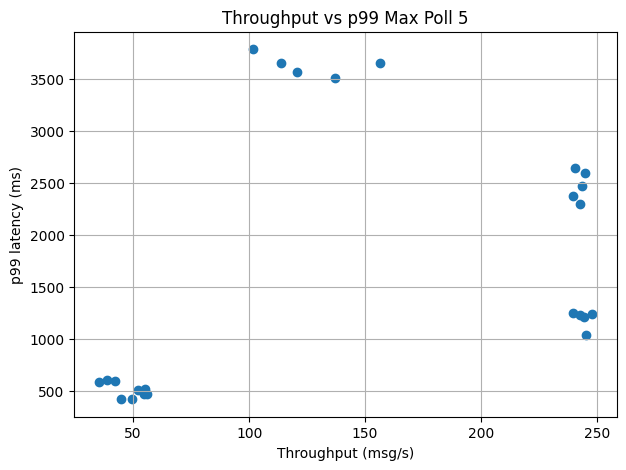

In [241]:
plt.figure(figsize=(14,5))

for pod, g in metrics_fixed.groupby("pod"):

    plt.plot(
        g["uptime_sec"],
        g["true_msg_rate"],
        marker="o",
        linewidth=1,
        label=pod
    )

plt.xlabel("Time (sec)")
plt.ylabel("Corrected throughput (msg/s)")

plt.title(f"Consumer Throughput Over Time Max Poll {POLL_MAX_MSG}")

plt.legend(fontsize=8)

plt.grid(True)

plt.savefig(
    OUTPUT_DIR / f"throughput_over_time_corrected_{POLL_MAX_MSG}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.figure(figsize=(7,5))

plt.scatter(
    metrics_fixed["true_msg_rate"],
    metrics_fixed["lat_p99_ms"]
)

plt.xlabel("Throughput (msg/s)")
plt.ylabel("p99 latency (ms)")

plt.title(f"Throughput vs p99 Max Poll {POLL_MAX_MSG}")

plt.grid(True)

plt.savefig(
    OUTPUT_DIR /f"throughput_vs_p99_corrected_{POLL_MAX_MSG}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

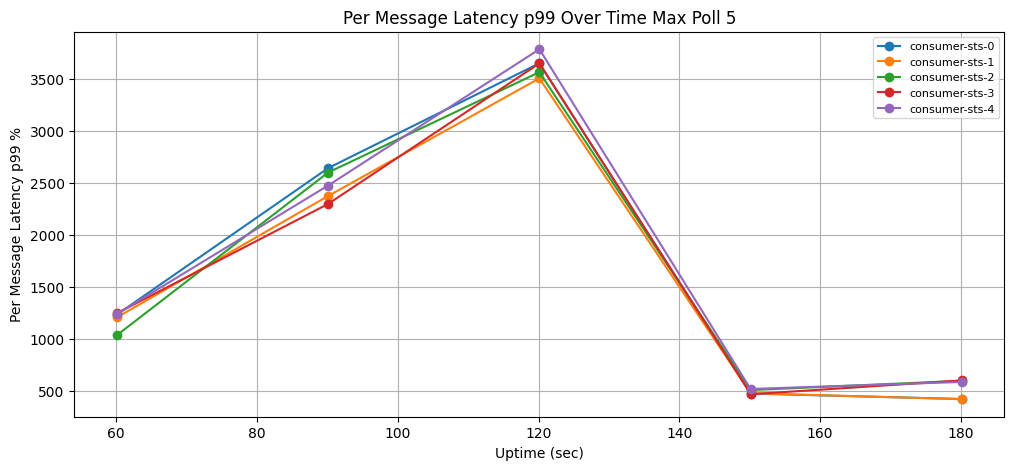

In [242]:
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)

for pod, g in metrics_df.groupby("pod"):

    plt.plot(
        g["uptime_sec"],
        g["lat_p99_ms"],
        marker="o",
        label=pod
    )
    
plt.xlabel("Uptime (sec)")
plt.ylabel("Per Message Latency p99 %")
plt.title(f"Per Message Latency p99 Over Time Max Poll {POLL_MAX_MSG}")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig(figures_dir / f"per_msg_latency_over_time_{POLL_MAX_MSG}.png", dpi=300, bbox_inches="tight")


In [243]:
print(metrics_df["cpu_percent"].describe())
print("----------------------------------")
print(metrics_df["mem_percent"].describe())

count    25.000000
mean     17.104000
std       8.338039
min       3.800000
25%      12.300000
50%      14.600000
75%      24.700000
max      38.600000
Name: cpu_percent, dtype: float64
----------------------------------
count    25.000000
mean     13.216000
std       7.434698
min       5.700000
25%       6.200000
50%      12.500000
75%      15.800000
max      25.800000
Name: mem_percent, dtype: float64


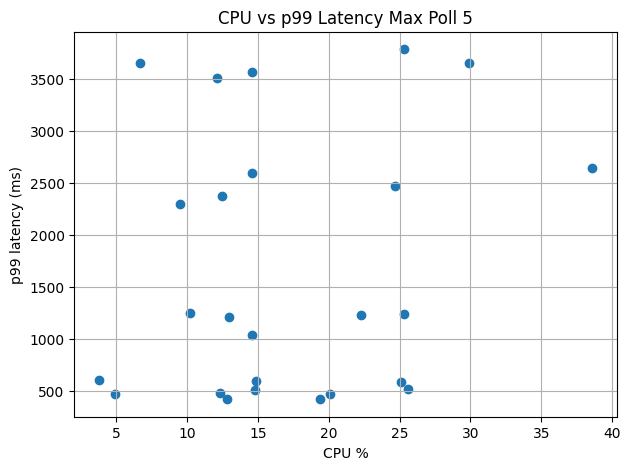

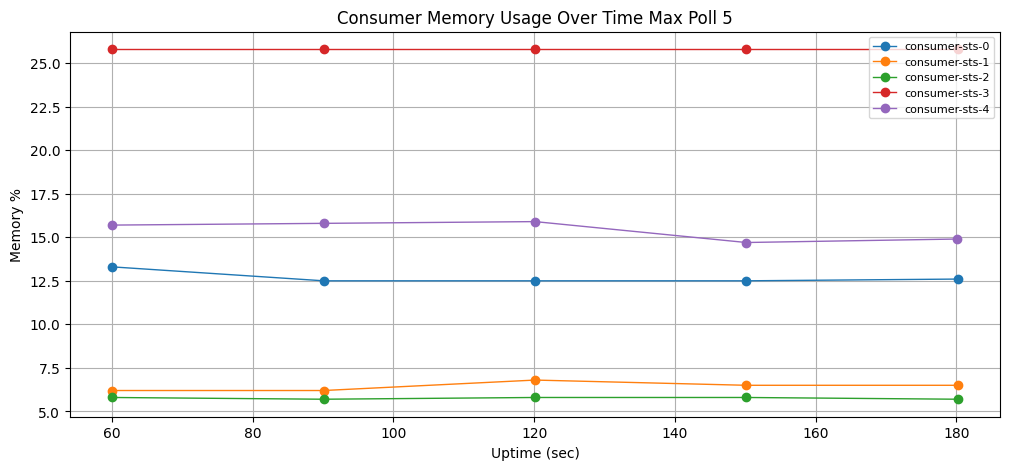

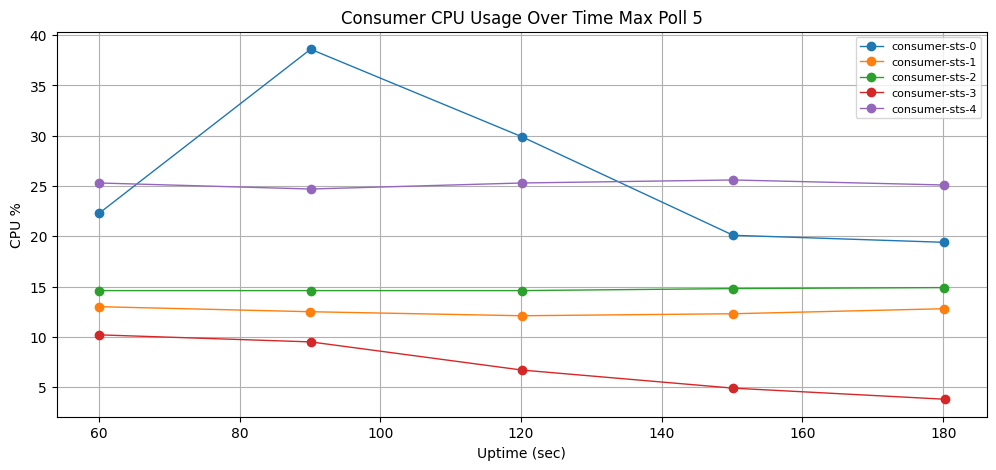

In [244]:
plt.figure(figsize=(7,5))

plt.scatter(
    metrics_df["cpu_percent"],
    metrics_df["lat_p99_ms"]
)

plt.xlabel("CPU %")
plt.ylabel("p99 latency (ms)")
plt.title(f"CPU vs p99 Latency Max Poll {POLL_MAX_MSG}")
plt.grid(True)

plt.savefig(figures_dir / f"cpu_vs_p99_latency_max_poll_{POLL_MAX_MSG}.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(12,5))

for pod, g in metrics_df.groupby("pod"):
    plt.plot(
        g["uptime_sec"],
        g["mem_percent"],
        marker="o",
        linewidth=1,
        label=pod
    )

plt.xlabel("Uptime (sec)")
plt.ylabel("Memory %")
plt.title(f"Consumer Memory Usage Over Time Max Poll {POLL_MAX_MSG}")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig(figures_dir / f"consumer_memory_over_time_max_poll_{POLL_MAX_MSG}.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(12,5))

for pod, g in metrics_df.groupby("pod"):
    plt.plot(
        g["uptime_sec"],
        g["cpu_percent"],
        marker="o",
        linewidth=1,
        label=pod
    )

plt.xlabel("Uptime (sec)")
plt.ylabel("CPU %")
plt.title(f"Consumer CPU Usage Over Time Max Poll {POLL_MAX_MSG}")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig(figures_dir / f"consumer_cpu_over_time_max_poll_{POLL_MAX_MSG}.png", dpi=300, bbox_inches="tight")

plt.show()

In [245]:
summary_stats = metrics_df[
    ["lat_p99_ms", "msg_rate_window"]
].describe()

summary_stats.to_csv(
    OUTPUT_DIR / f"latency_throughput_describe{POLL_MAX_MSG}.csv"
)
summary_stats

,lat_p99_ms,msg_rate_window
count,25.000000,25.000000
mean,1665.385440,141.691521
std,1247.081427,89.836861
min,422.996000,35.299560
25%,521.454000,54.472497
50%,1235.248000,120.783745
75%,2601.402000,242.774192
max,3786.977000,247.769291


In [246]:
(
    metrics_df["max_lag"] > 0
).mean()

0.8